### Import Pandas, Numpy, Matplotlib, Seaborn and Warning liberaries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import  OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import  RandomizedSearchCV , GridSearchCV, cross_val_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

In [3]:
# Load the dataset
df = pd.read_csv('data/stud.csv')

In [4]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
X=df.drop('math_score',axis=1)
y=df['math_score']

In [6]:
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [7]:
X.shape

(1000, 7)

In [8]:
X.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
reading_score                  72
writing_score                  77
dtype: int64

In [9]:
y.head()

0    72
1    69
2    90
3    47
4    76
Name: math_score, dtype: int64

In [10]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   reading_score                1000 non-null   int64 
 6   writing_score                1000 non-null   int64 
dtypes: int64(2), object(5)
memory usage: 54.8+ KB


In [11]:
X.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
reading_score                  72
writing_score                  77
dtype: int64

In [12]:
# Create ColumnTransformer for preprocessing

numerical_features = X.select_dtypes(exclude='object').columns
categorical_features = X.select_dtypes(include='object').columns

numeric_transformer= StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore',drop='first')

preprocessor= ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)
X=preprocessor.fit_transform(X)

In [13]:
X.shape

(1000, 14)

In [14]:
# Separate the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 14), (200, 14), (800,), (200,))

### Create an Evaluate Function to give all metrics after model Training

In [15]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse=np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    print(f'MAE: {mae:.2f}')
    print(f'MSE: {mse:.2f}')
    print(f'RMSE: {rmse:.2f}')
    print(f'R² Score: {r2:.2f}')

In [16]:
models = {
    'Linear Regression': LinearRegression(),
    'Lasso Regression': Lasso(),
    'Ridge Regression': Ridge(),
    'KNN Regressor': SVR(kernel='rbf'),
    'Decision Tree Regressor': DecisionTreeRegressor(),
    'Random Forest Regressor': RandomForestRegressor(),
    'XGBoost Regressor': XGBRegressor(),
    'CatBoost Regressor': CatBoostRegressor(verbose=0),
    'AdaBoost Regressor': GradientBoostingRegressor()

}

model_list = []
r2_list= []

for i in range(len(models)):
    model_name = list(models.keys())[i]
    model = list(models.values())[i]
    model.fit(X_train, y_train)
    print(f'{model_name} Performance:')
    evaluate_model(model, X_test, y_test)
    r2_list.append(r2_score(y_test, model.predict(X_test)))
    model_list.append(model_name)
    print('---'*10)


Linear Regression Performance:
MAE: 4.21
MSE: 29.10
RMSE: 5.39
R² Score: 0.88
------------------------------
Lasso Regression Performance:
MAE: 5.16
MSE: 42.51
RMSE: 6.52
R² Score: 0.83
------------------------------
Ridge Regression Performance:
MAE: 4.21
MSE: 29.09
RMSE: 5.39
R² Score: 0.88
------------------------------
KNN Regressor Performance:
MAE: 5.50
MSE: 69.83
RMSE: 8.36
R² Score: 0.71
------------------------------
Decision Tree Regressor Performance:
MAE: 6.30
MSE: 63.51
RMSE: 7.97
R² Score: 0.74
------------------------------
Random Forest Regressor Performance:
MAE: 4.63
MSE: 35.85
RMSE: 5.99
R² Score: 0.85
------------------------------
XGBoost Regressor Performance:
MAE: 5.13
MSE: 43.58
RMSE: 6.60
R² Score: 0.82
------------------------------
CatBoost Regressor Performance:
MAE: 4.63
MSE: 36.55
RMSE: 6.05
R² Score: 0.85
------------------------------
AdaBoost Regressor Performance:
MAE: 4.29
MSE: 31.02
RMSE: 5.57
R² Score: 0.87
------------------------------


### Results

In [17]:
pd.DataFrame(list(zip(model_list,r2_list)),columns=['Model','R2 Score']).sort_values(by='R2 Score',ascending=False).round(4)

,Model,R2 Score
2,Ridge Regression,0.8805
0,Linear Regression,0.8804
8,AdaBoost Regressor,0.8725
5,Random Forest Regressor,0.8527
7,CatBoost Regressor,0.8498
1,Lasso Regression,0.8253
6,XGBoost Regressor,0.8209
4,Decision Tree Regressor,0.7390
3,KNN Regressor,0.7130


### Linear Regression

In [18]:
linear_model=LinearRegression(fit_intercept=True)
linear_model=linear_model.fit(X_train,y_train)
y_pred=linear_model.predict(X_test)
score=r2_score(y_test,y_pred)
print('Acuracy of the model is %.2f '%score)

Acuracy of the model is 0.88 


### Plot y_pred and y_test

Text(0, 0.5, 'predicted')

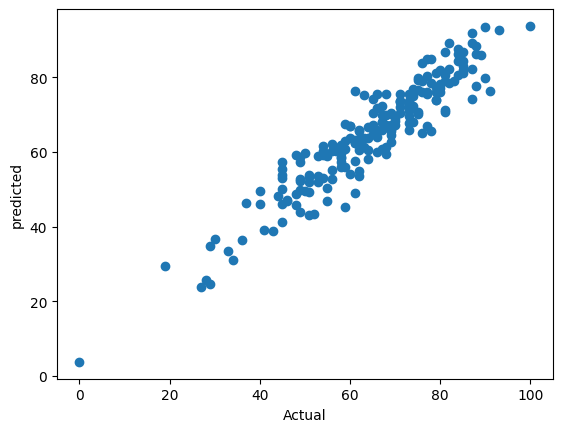

In [19]:
plt.scatter(y_test,y_pred)
plt.xlabel('Actual')
plt.ylabel('predicted')

<Axes: xlabel='math_score'>

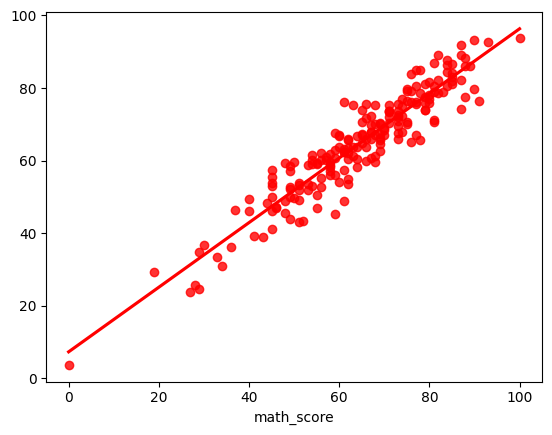

In [25]:
sns.regplot(x=y_test,y=y_pred,ci=None,color='red')

### Difference between Actual and Predicted

In [27]:
pred_df=pd.DataFrame({'Actual Value': y_test, 'Predicted Value': y_pred, 'Difference': y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
